# BTM Analysis
Analysis done at the request of BTM for the purpose of cell selection.

In [1]:
from data_tools import TimeSeries, InfluxClient

In [2]:
day_1_start = "2024-07-16T14:00:00Z"
day_3_end = "2024-07-18T19:00:00Z"

battery_current: TimeSeries = InfluxClient().query_time_series(day_1_start, day_3_end, field="PackCurrent", units="A")

/Users/joshuariefman/Solar/data_analysis/venv/lib/python3.11/site-packages/data_tools/time_series.py:298: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "car": query_df["car"][0],
/Users/joshuariefman/Solar/data_analysis/venv/lib/python3.11/site-packages/data_tools/time_series.py:299: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "measurement": query_df["_measurement"][0],


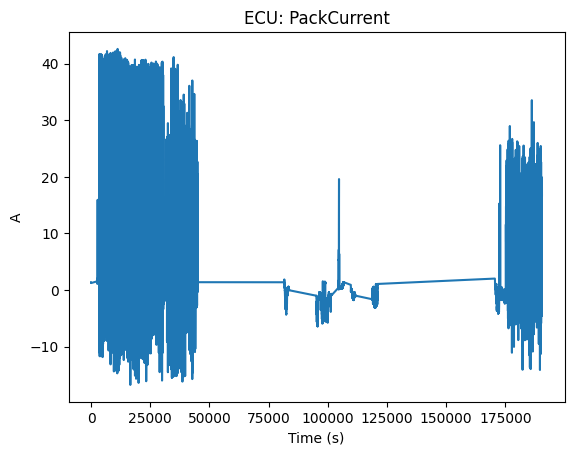

In [3]:
battery_current.plot()

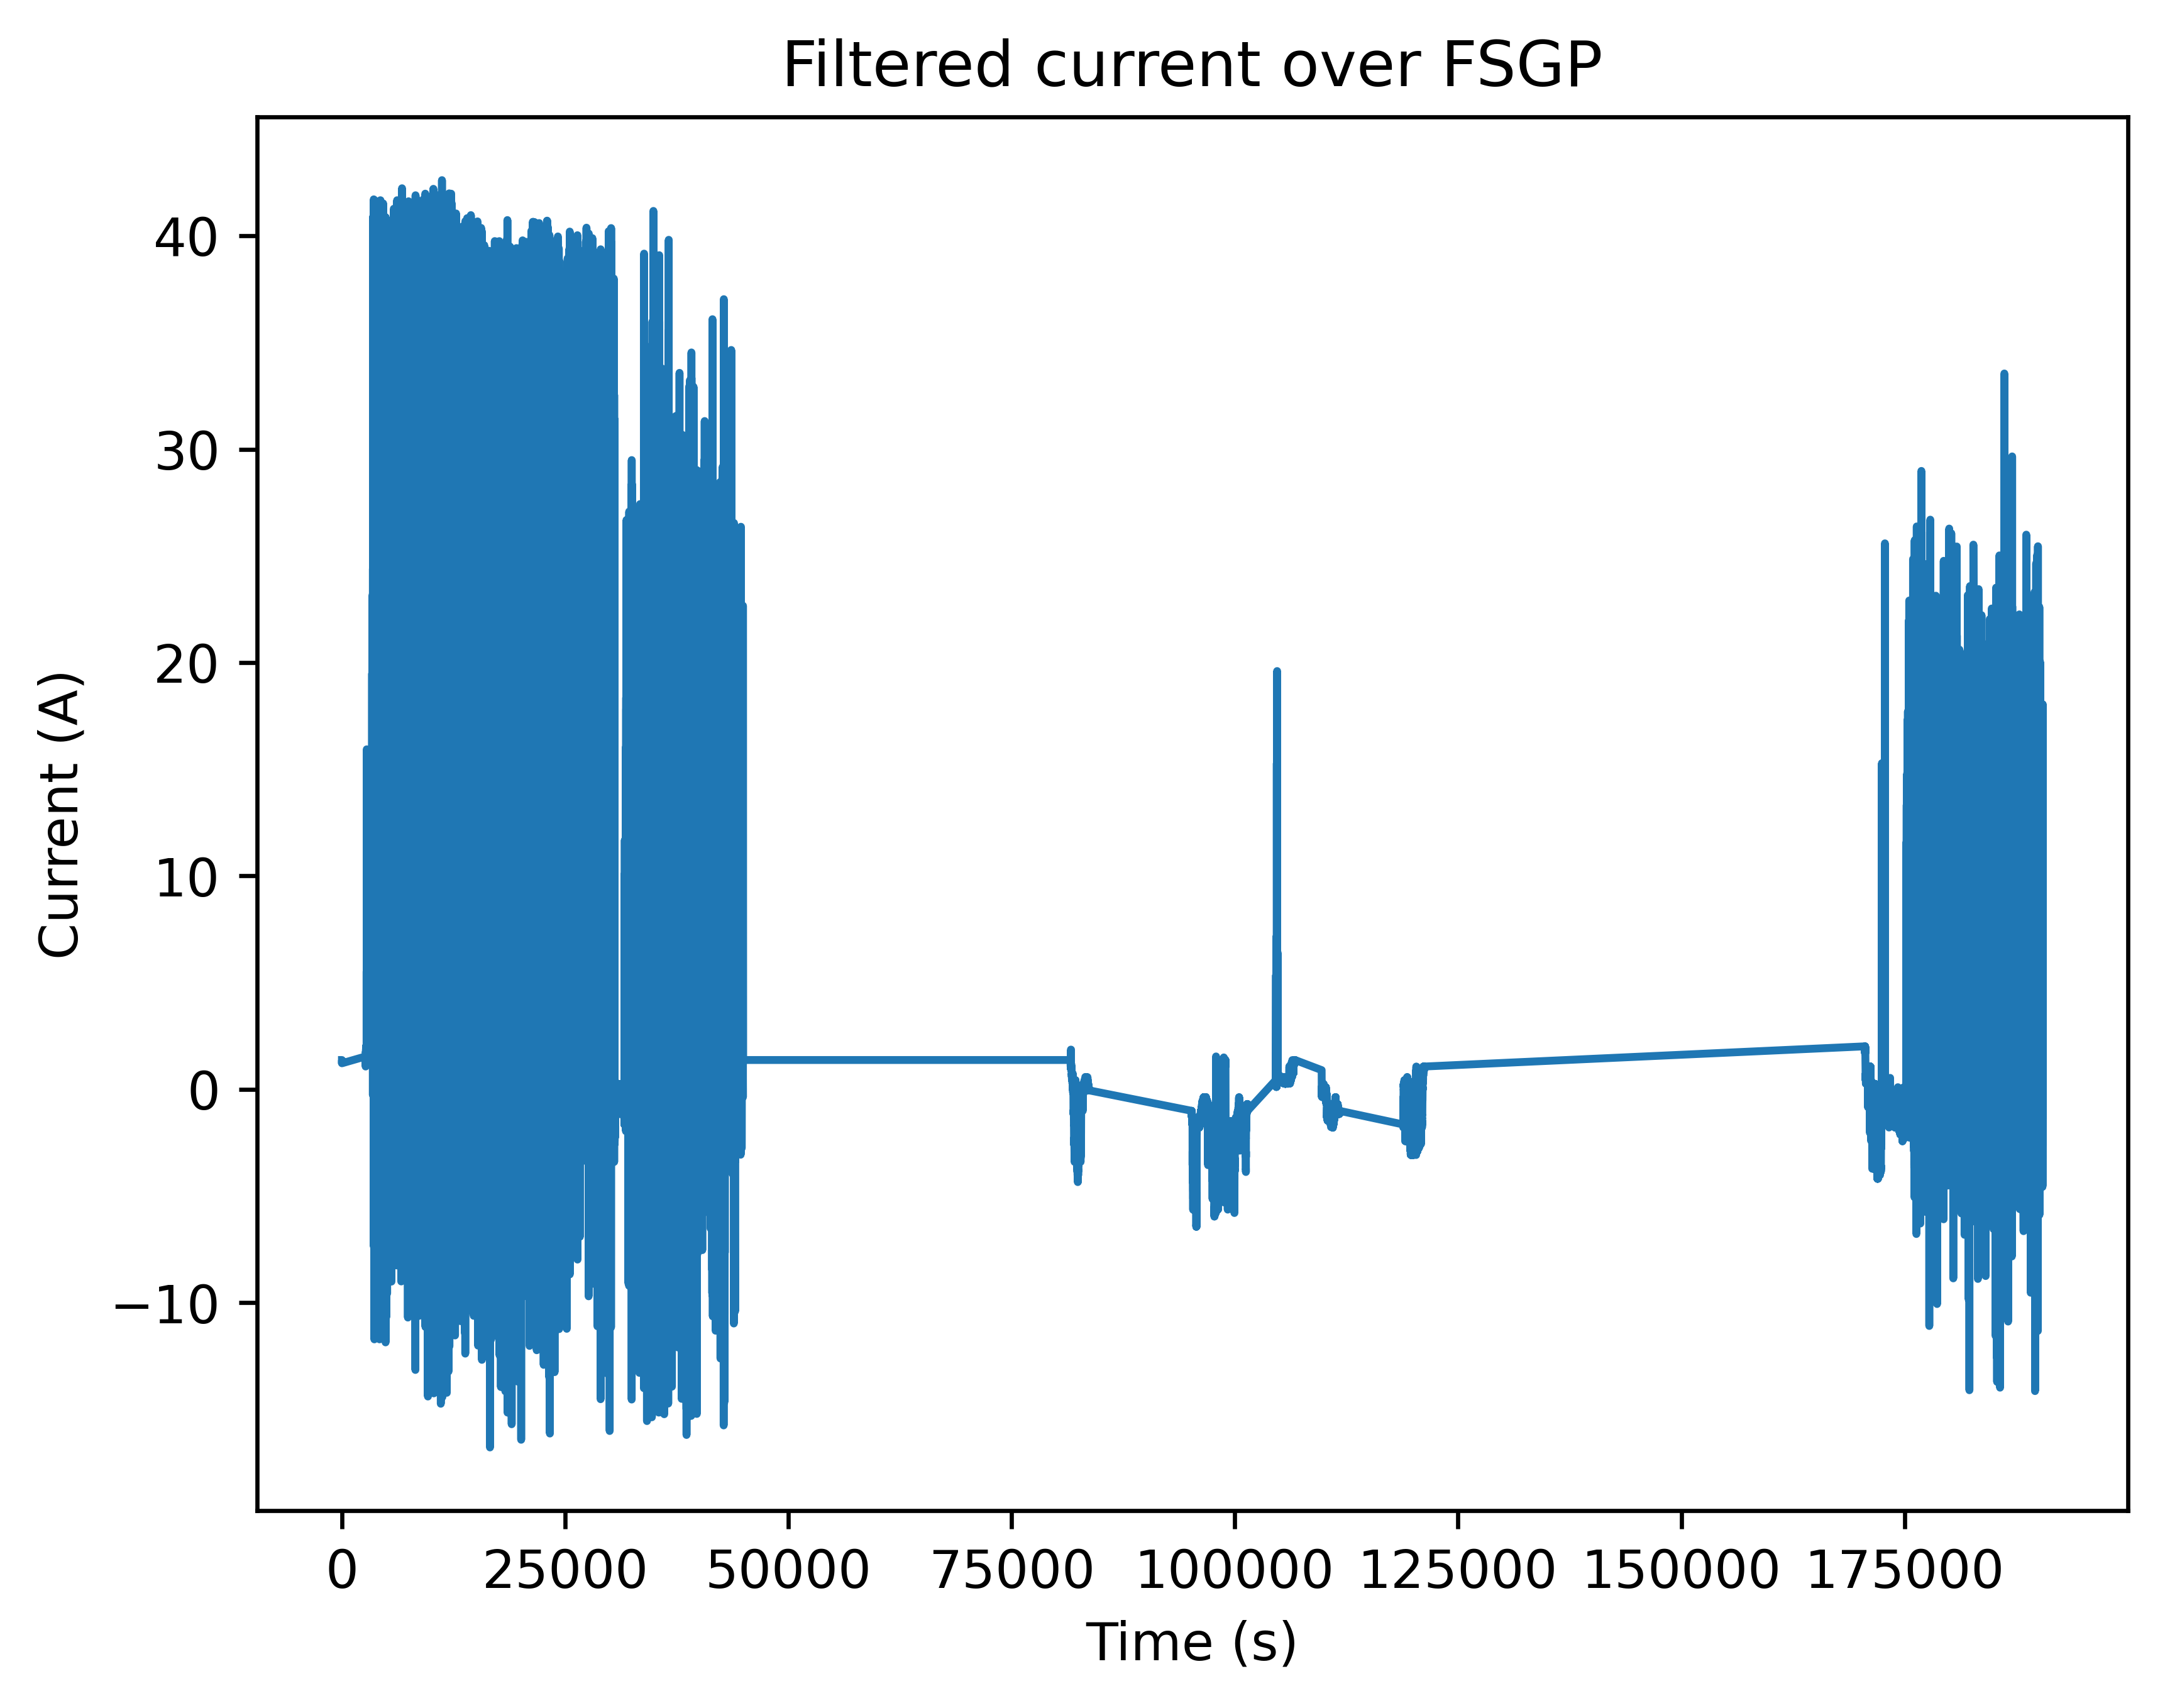

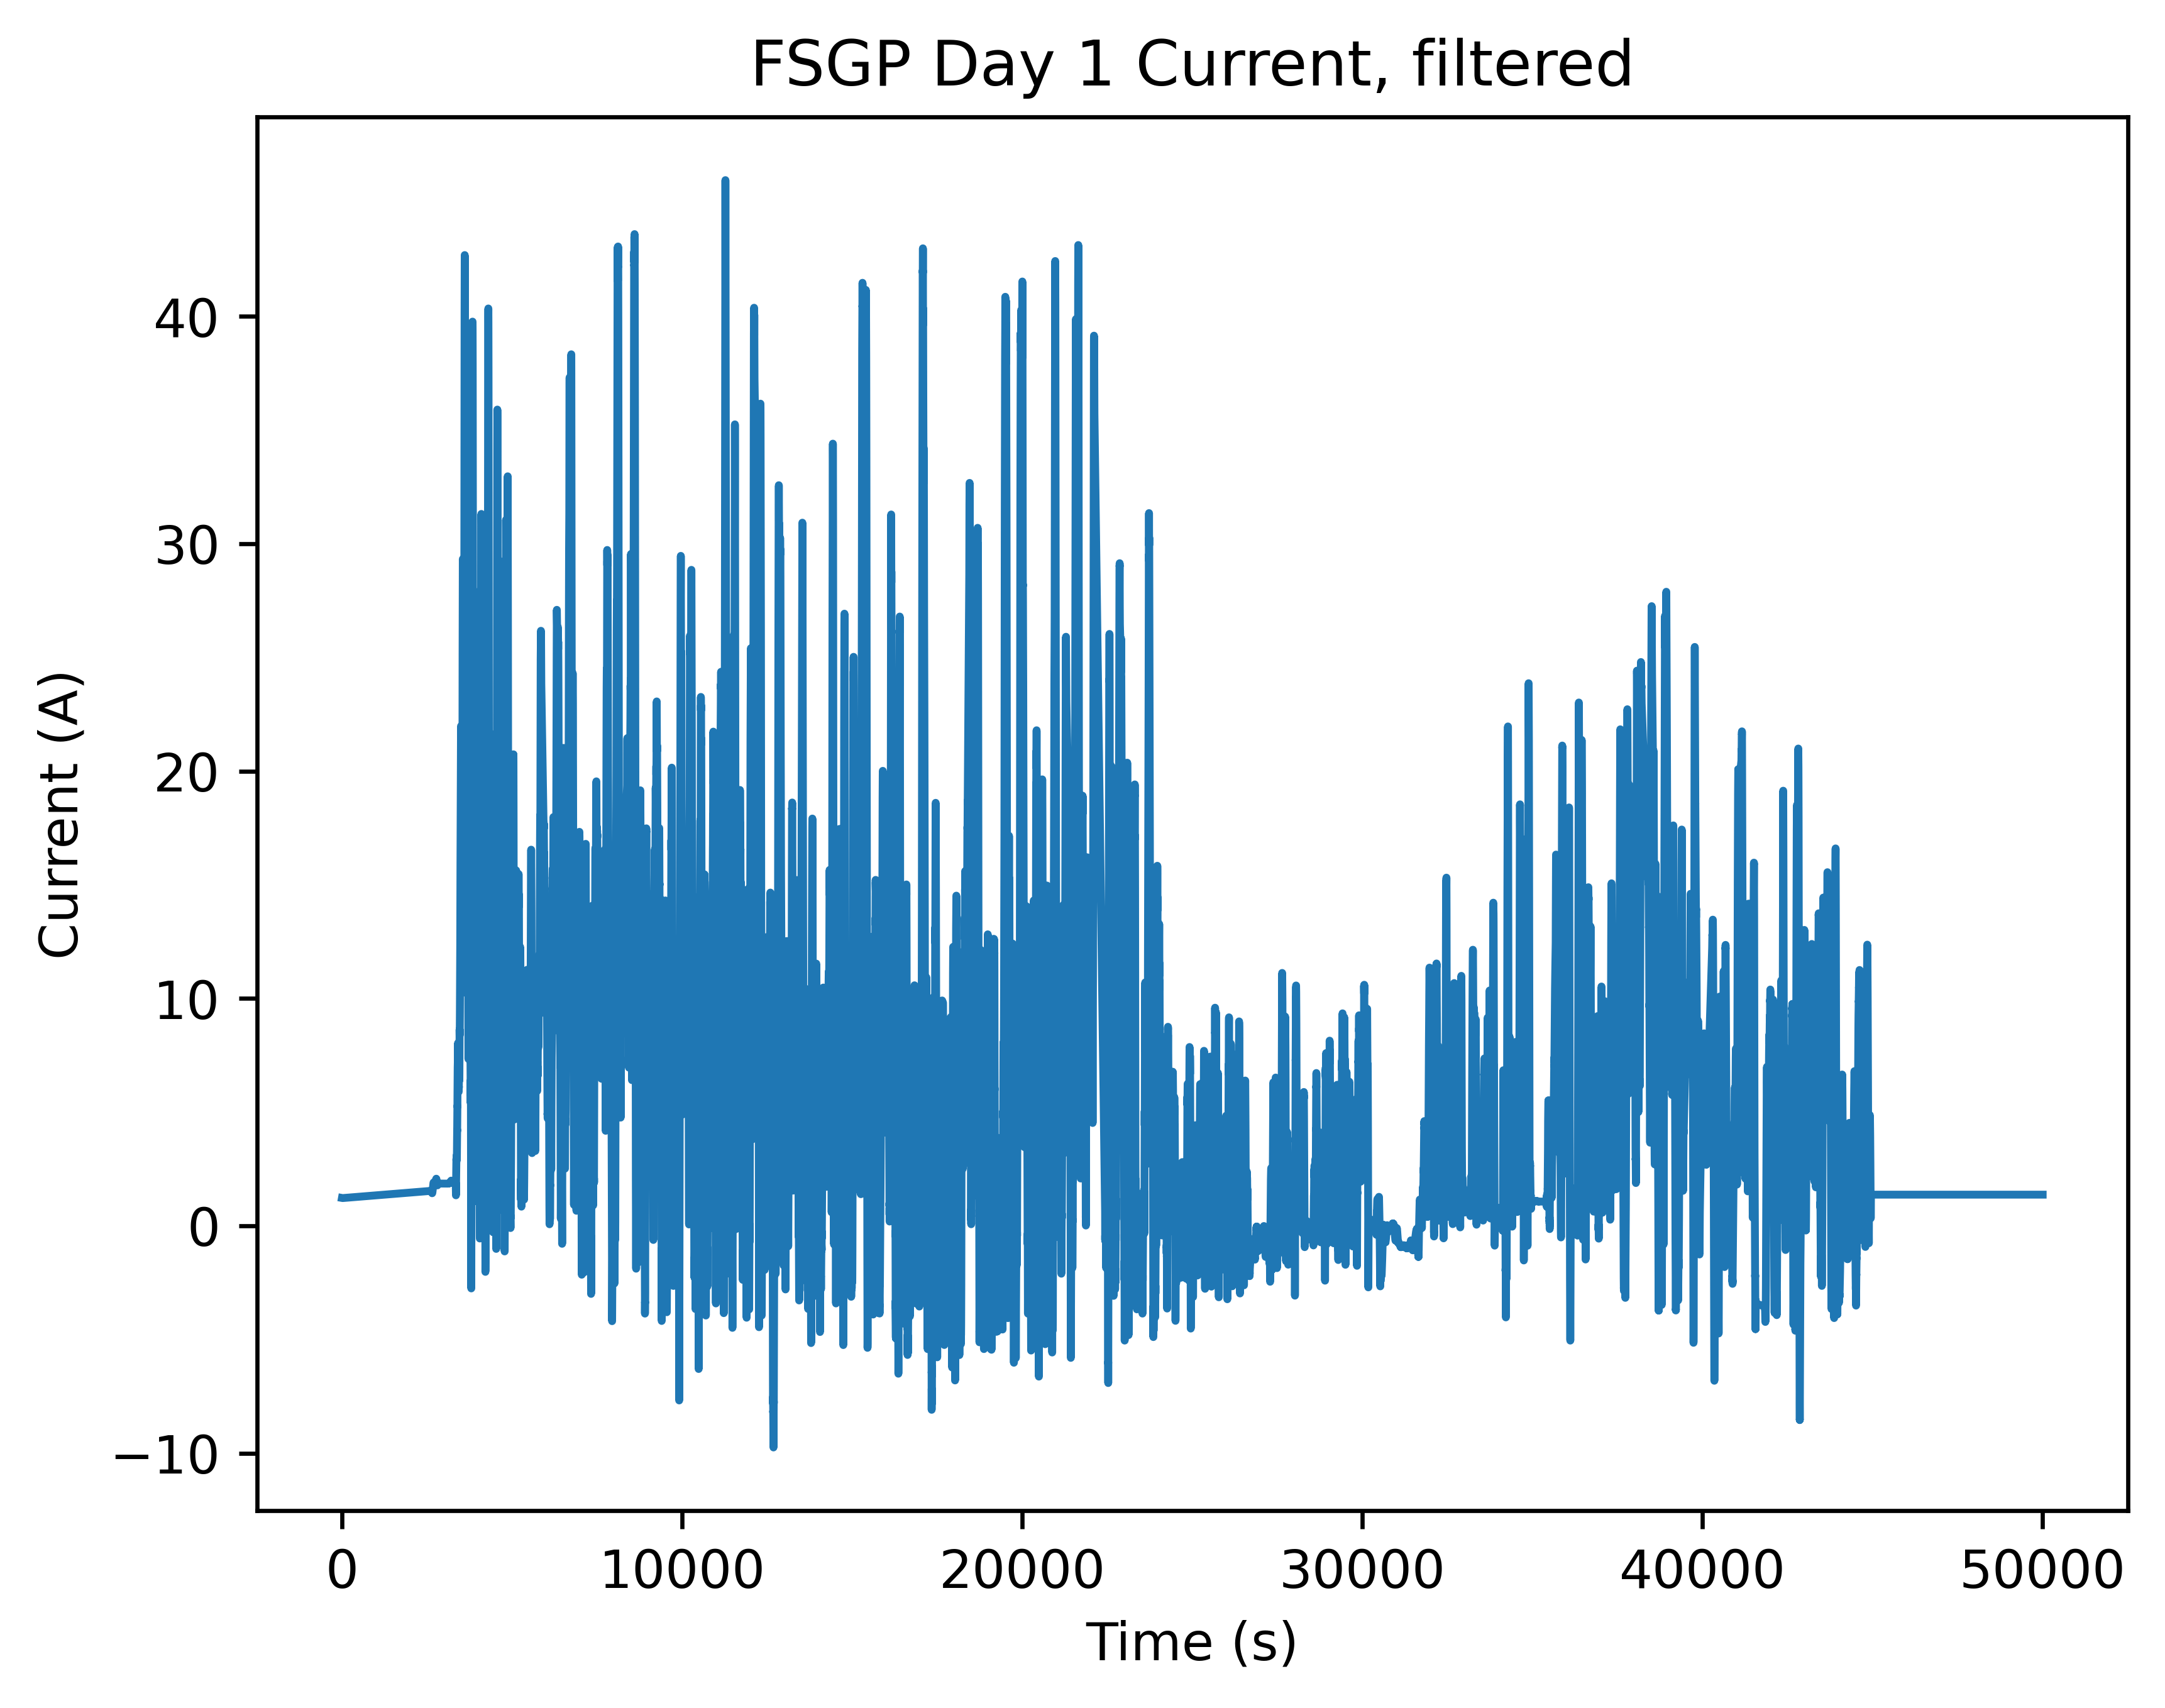

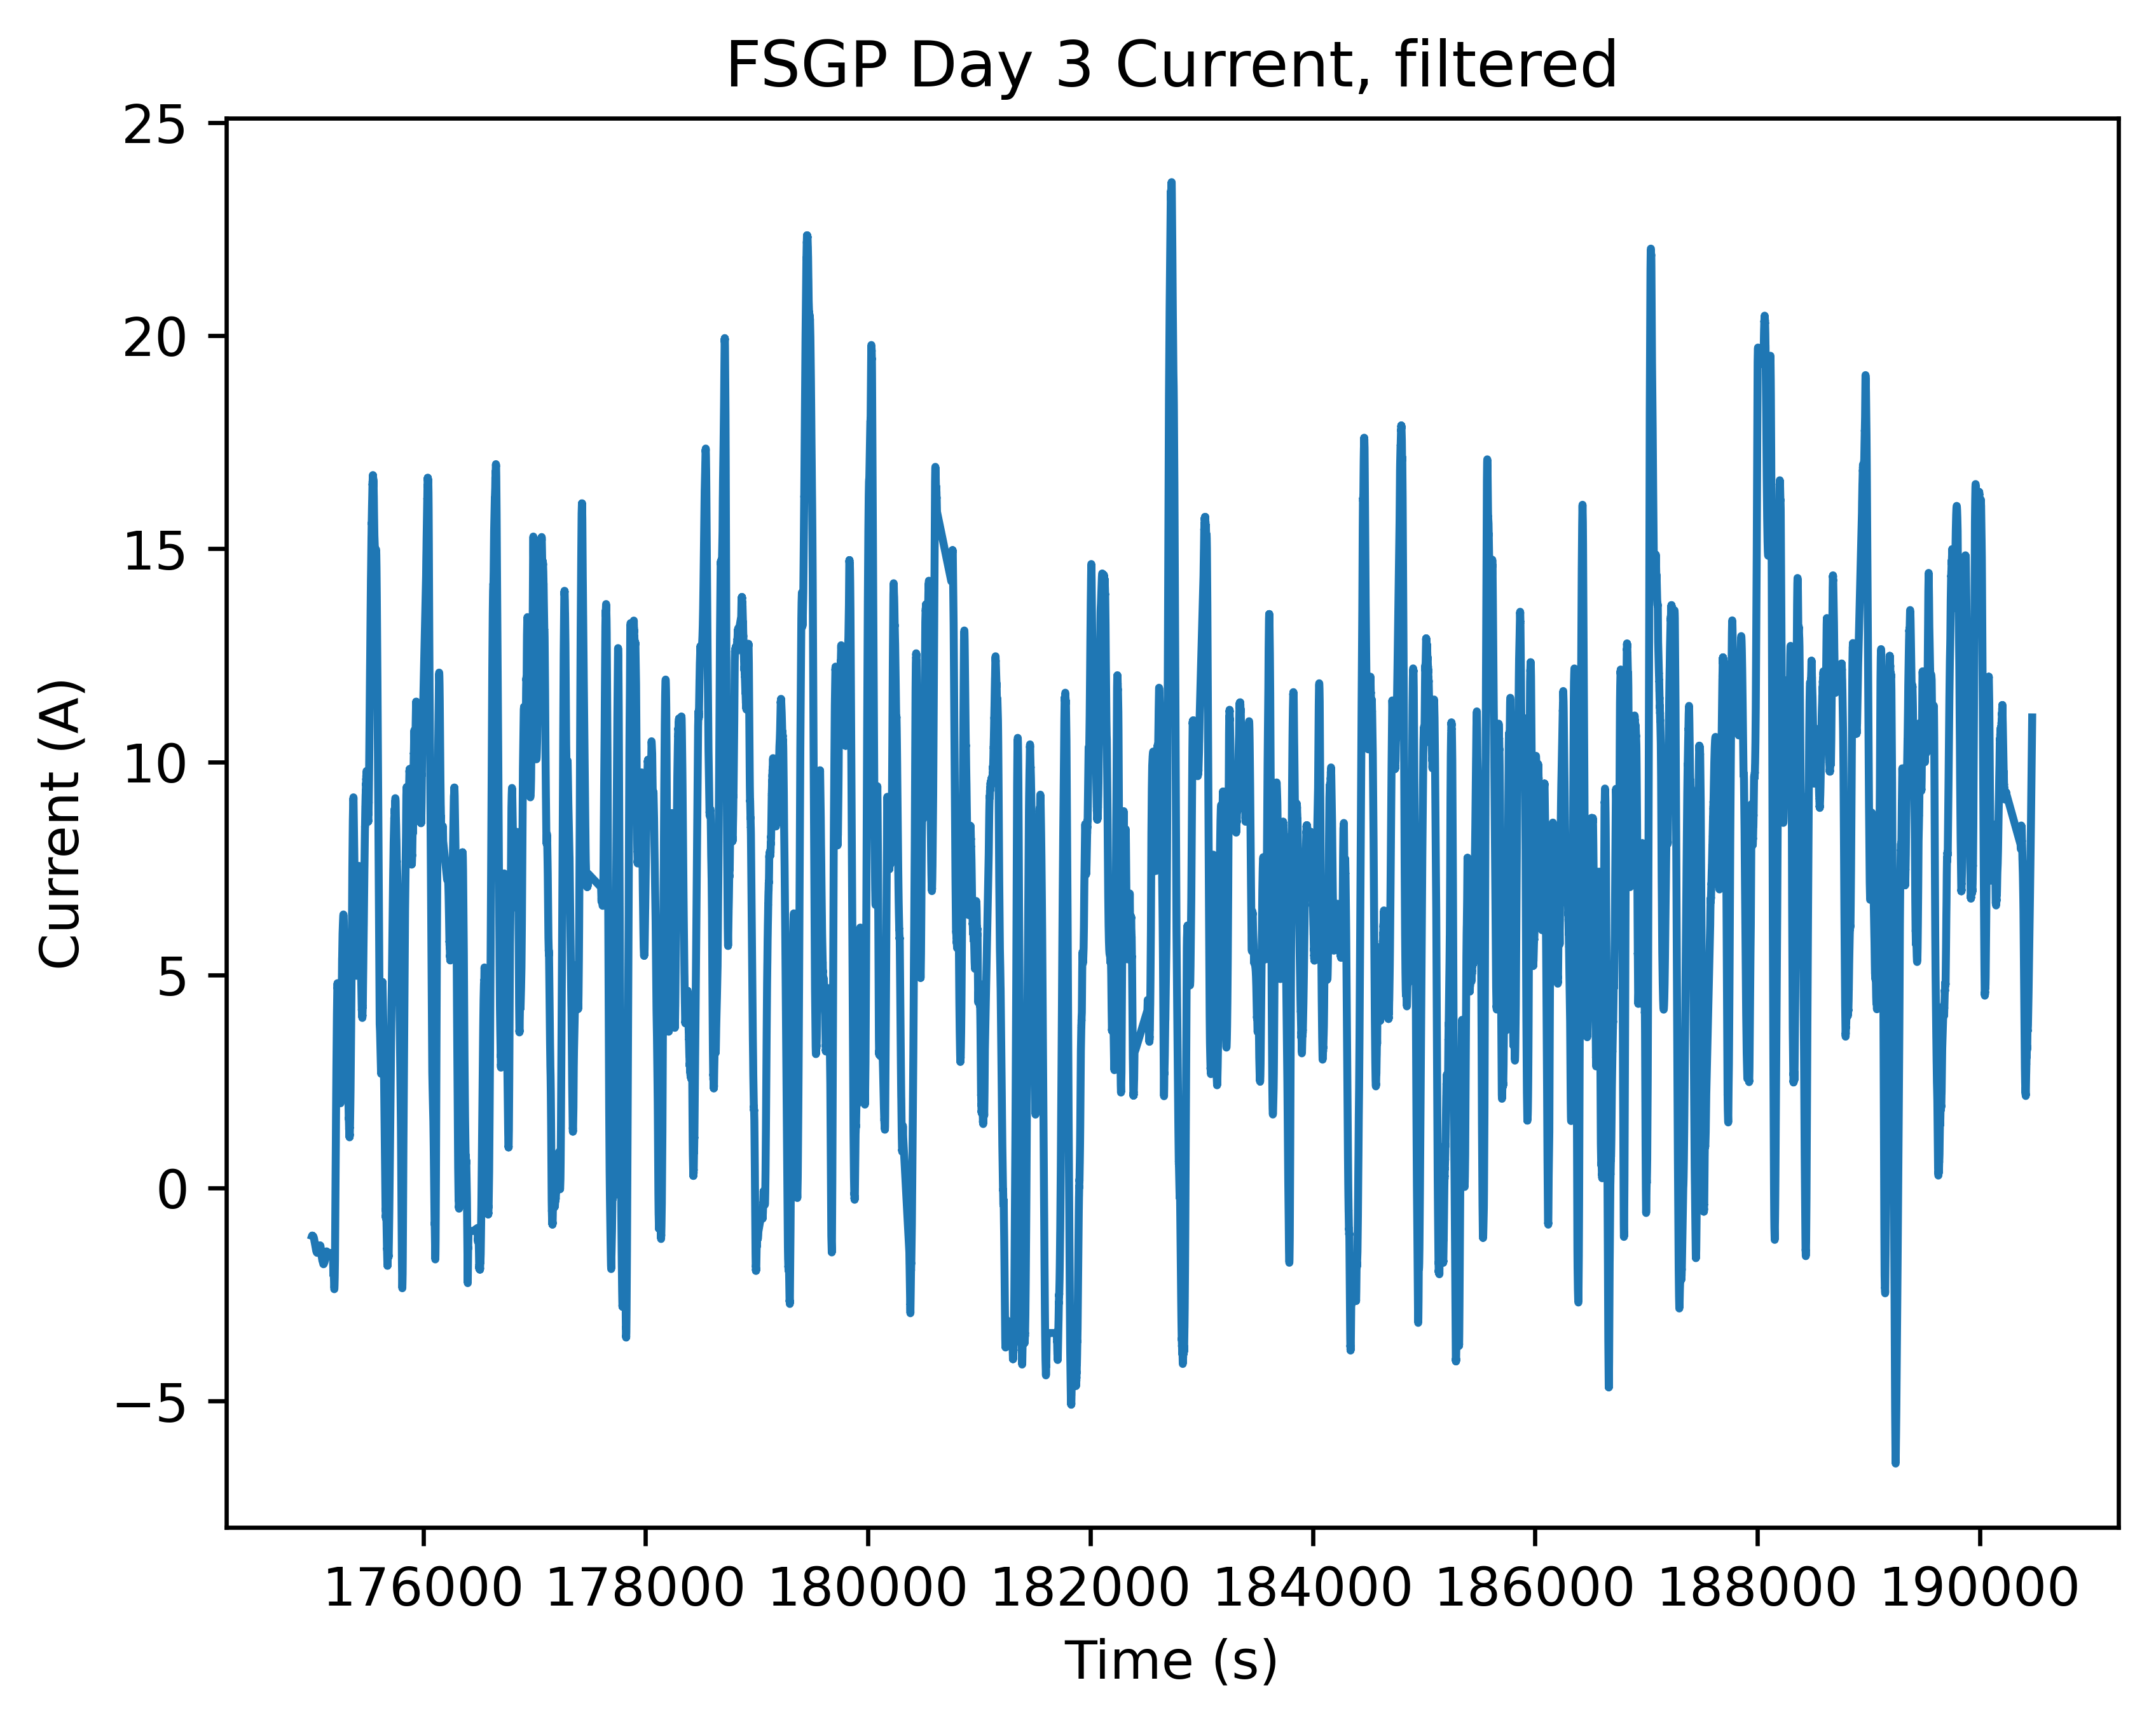

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 600
from scipy import signal
import numpy as np

def plot_current(x_axis, current: TimeSeries, title: str):
    fig, ax = plt.subplots()

    ax.plot(x_axis, current, label="Battery Current")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Current (A)")
    ax.set_title(title)

    plt.show()

battery_current_filtered = battery_current.promote(signal.savgol_filter(battery_current, 600, 2))

plot_current(battery_current_filtered.x_axis, np.array(battery_current), "Filtered current over FSGP")

plot_current(battery_current_filtered.x_axis[:500000], np.array(battery_current_filtered)[:500000], "FSGP Day 1 Current, filtered")
plot_current(battery_current_filtered.x_axis[1750000:], np.array(battery_current_filtered)[1750000:], "FSGP Day 3 Current, filtered")

In [5]:
battery_current_day_1 = np.array(battery_current_filtered)[:500000]
battery_current_day_2 = np.array(battery_current_filtered)[1750000:]

battery_current_day_1_nonzero = battery_current_day_1[np.where(np.abs(battery_current_day_1) > 1.0)]
battery_current_day_2_nonzero = battery_current_day_2[np.where(np.abs(battery_current_day_2) > 1.0)]

average_day_1_current = np.mean(battery_current_day_1_nonzero)
average_day_3_current = np.mean(battery_current_day_2_nonzero)
print(f"Average Day 1 Current: {average_day_1_current:.1f}")
print(f"Average Day 3 Current: {average_day_3_current:.1f}")

print(f"Day 1 Charge (integral of current): {np.trapezoid(battery_current_day_1, dx=battery_current_filtered.granularity):.1f}")
print(f"Day 3 Charge (integral of current): {np.trapezoid(battery_current_day_2, dx=battery_current_filtered.granularity):.1f}")

Average Day 1 Current: 6.7
Average Day 3 Current: 7.6
Day 1 Charge (integral of current): 288270.6
Day 3 Charge (integral of current): 110984.3
